In [1]:
import pickle, gzip
import pandas as pd
import numpy as np
import copy
from pathlib import Path
from itertools import zip_longest

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [3]:
def save_y_and_params(y_dict, params, out_path, compress=True):
    """
    y_dict: e.g. {"train": y_train, "val": y_val, "test": y_test}
    params: dict of hyperparameters/config
    out_path: path to .pkl or .pkl.gz
    """
    payload = {"y": y_dict, "params": params}
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    opener = gzip.open if compress else open
    with opener(out_path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_y_and_params(path, compressed=True):
    opener = gzip.open if compressed else open
    with opener(path, "rb") as f:
        payload = pickle.load(f)
    return payload["y"], payload["params"]

In [4]:
(_, params5) = load_y_and_params("../results/data/mix/r100_y_and_params5.pkl", compressed=False)
(_, params4) = load_y_and_params("../results/data/mix/r100_y_and_params4.pkl", compressed=False)
(_, params3) = load_y_and_params("../results/data/mix/r100_y_and_params3.pkl", compressed=False)
(_, params6) = load_y_and_params("../results/data/mix/r100_y_and_params6.pkl", compressed=False)
(_, params7) = load_y_and_params("../results/data/mix/r100_y_and_params7.pkl", compressed=False)

In [5]:
import heapq
df = pd.DataFrame(zip_longest(params3['r2'], params4['r2'], params5['r2'],params6['r2'], params7['r2']),
                 columns=['3', '4', '5', '6', '7'])

/lsf_tmp/278459617.tmpdir/ipykernel_1452296/2291462108.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


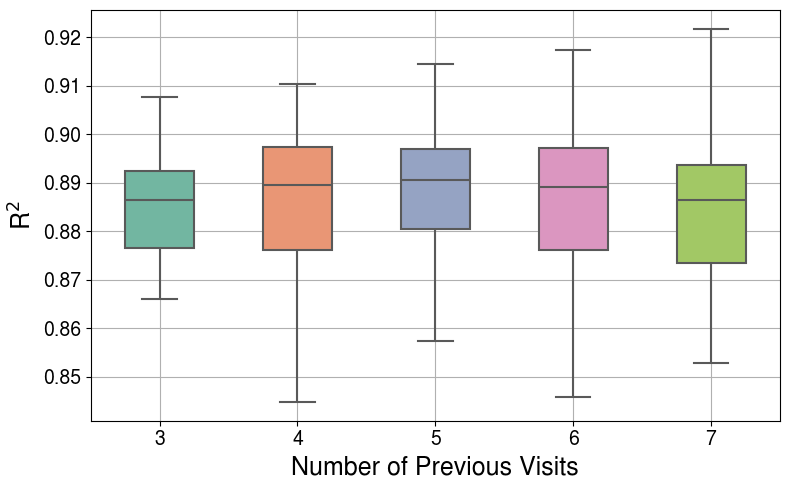

In [8]:
df_long = df.melt(var_name="Variable", value_name="Value")

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_long,
    x="Variable",
    y="Value",
    showfliers=False,    
    palette="Set2",
    width=0.5,
    linewidth=1.5
)
plt.xlabel("Number of Previous Visits", fontsize=18)
plt.ylabel("R$^2$", fontsize=18)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.grid()
plt.tight_layout()
# plt.title("R$^2$ vs. Number of previous Visits for Next Prediction ")
plt.savefig('../results/figures/summary/r2_num_visits.pdf')
plt.show()